In [11]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
from matplotlib.pyplot import figure

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (12,8)

# read in data

df = pd.read_csv(r'/Users/markj/Documents/python/Fruit-Prices-2022.csv')

In [2]:
# peek at the data

df.head()

,Fruit,Form,RetailPrice,RetailPriceUnit,Yield,CupEquivalentSize,CupEquivalentUnit,CupEquivalentPrice
0,Apples,Fresh,1.8541,per pound,0.90,0.2425,pounds,0.4996
1,"Apples, applesauce",Canned,1.1705,per pound,1.00,0.5401,pounds,0.6323
2,"Apples, ready-to-drink",Juice,0.8699,per pint,1.00,8.0000,fluid ounces,0.4349
3,"Apples, frozen concentrate",Juice,0.6086,per pint,1.00,8.0000,fluid ounces,0.3043
4,Apricots,Fresh,3.6162,per pound,0.93,0.3638,pounds,1.4145


In [3]:
# Check for missing data

for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

Fruit - 0%
Form - 0%
RetailPrice - 0%
RetailPriceUnit - 0%
Yield - 0%
CupEquivalentSize - 0%
CupEquivalentUnit - 0%
CupEquivalentPrice - 0%


In [15]:
print(df.dtypes)

Unique ID           int64
Indicator ID        int64
Name               object
Measure            object
Measure Info       object
Geo Type Name      object
Geo Join ID       float64
Geo Place Name     object
Time Period        object
Start_Date         object
Data Value        float64
Message           float64
dtype: object


In [5]:
# get rid of duplicates

df.drop_duplicates()

,Fruit,Form,RetailPrice,RetailPriceUnit,Yield,CupEquivalentSize,CupEquivalentUnit,CupEquivalentPrice
0,Apples,Fresh,1.8541,per pound,0.90,0.2425,pounds,0.4996
1,"Apples, applesauce",Canned,1.1705,per pound,1.00,0.5401,pounds,0.6323
2,"Apples, ready-to-drink",Juice,0.8699,per pint,1.00,8.0000,fluid ounces,0.4349
3,"Apples, frozen concentrate",Juice,0.6086,per pint,1.00,8.0000,fluid ounces,0.3043
4,Apricots,Fresh,3.6162,per pound,0.93,0.3638,pounds,1.4145
...,...,...,...,...,...,...,...,...
57,Raspberries,Fresh,7.7338,per pound,0.96,0.3197,pounds,2.5753
58,Raspberries,Frozen,6.1590,per pound,1.00,0.3307,pounds,2.0368
59,Strawberries,Fresh,2.9682,per pound,0.94,0.3197,pounds,1.0094
60,Strawberries,Frozen,3.3421,per pound,1.00,0.3307,pounds,1.1052


<Axes: >

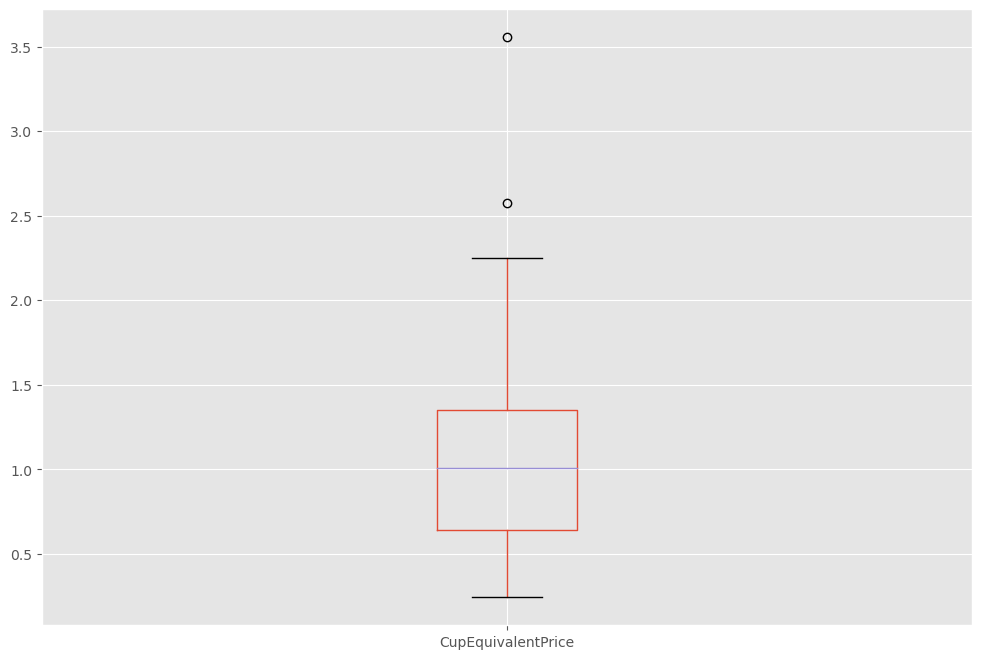

In [8]:
# Are there any Outliers?

df.boxplot(column=['CupEquivalentPrice'])


In [9]:
# order price by cup from highest to lowest

df.sort_values(by = 'CupEquivalentPrice', ascending = False, inplace = False)

,Fruit,Form,RetailPrice,RetailPriceUnit,Yield,CupEquivalentSize,CupEquivalentUnit,CupEquivalentPrice
16,"Cherries, packed in syrup or water",Canned,5.2418,per pound,0.65,0.4409,pounds,3.5558
57,Raspberries,Fresh,7.7338,per pound,0.96,0.3197,pounds,2.5753
10,Blackberries,Fresh,6.7483,per pound,0.96,0.3197,pounds,2.2471
58,Raspberries,Frozen,6.1590,per pound,1.00,0.3307,pounds,2.0368
15,Cherries,Fresh,4.6632,per pound,0.92,0.3417,pounds,1.7321
...,...,...,...,...,...,...,...,...
36,"Oranges, frozen concentrate",Juice,0.7338,per pint,1.00,8.0000,fluid ounces,0.3669
51,"Pineapple, frozen concentrate",Juice,0.7256,per pint,1.00,8.0000,fluid ounces,0.3628
8,Bananas,Fresh,0.5971,per pound,0.64,0.3307,pounds,0.3085
3,"Apples, frozen concentrate",Juice,0.6086,per pint,1.00,8.0000,fluid ounces,0.3043


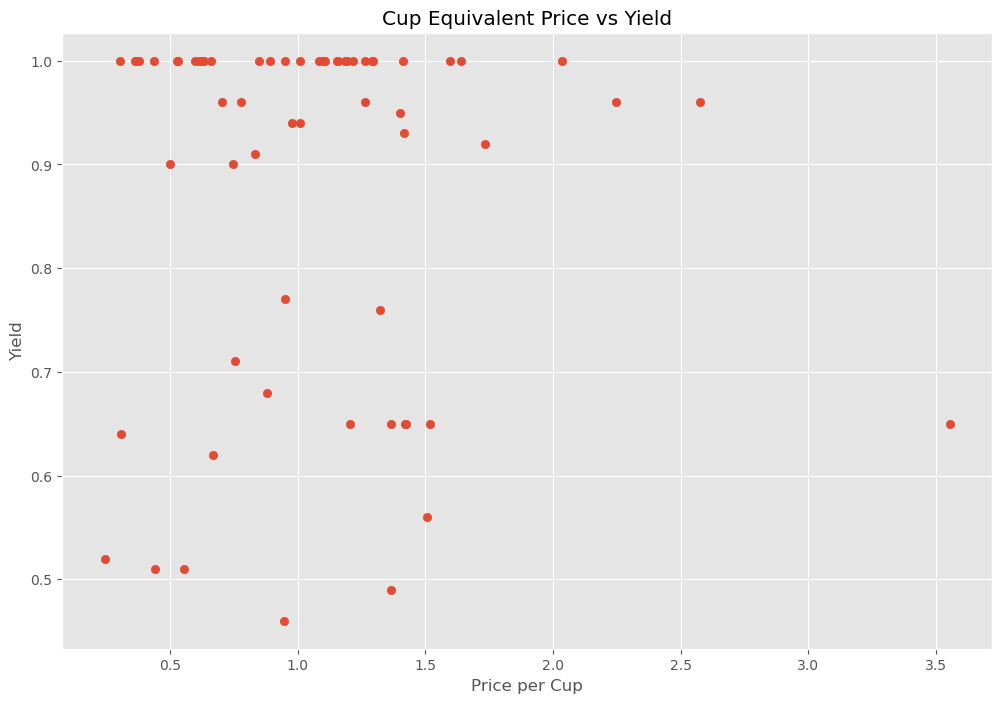

In [17]:
# Scatter plot of price per cup vs yield for fruit

plt.scatter(x = df['CupEquivalentPrice'], y = df['Yield'])
plt.title('Cup Equivalent Price vs Yield')
plt.xlabel('Price per Cup')
plt.ylabel('Yield')
plt.show()

<Axes: xlabel='CupEquivalentPrice', ylabel='Yield'>

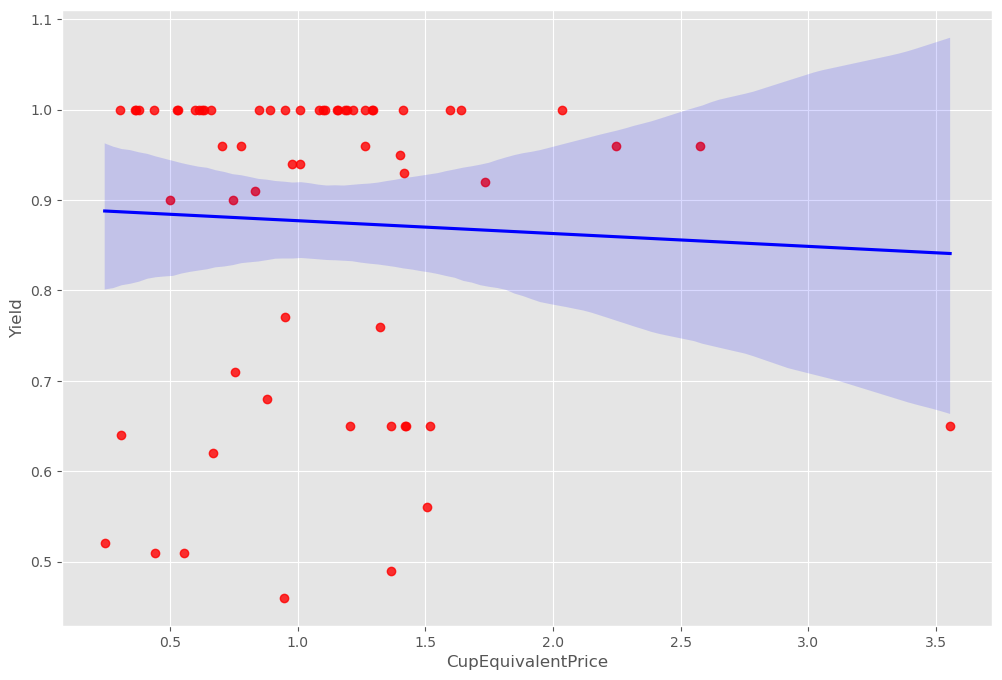

In [18]:
sns.regplot(x="CupEquivalentPrice", y="Yield", data=df, scatter_kws = {"color" : "red"}, line_kws = {"color": "blue"})

In [22]:
# differnet correlation methods: pearson, kendall, spearman

df.corr(method = 'pearson', numeric_only = 'default')

,RetailPrice,Yield,CupEquivalentSize,CupEquivalentPrice
RetailPrice,1.000000,0.367063,-0.391980,0.578283
Yield,0.367063,1.000000,0.321769,-0.046928
CupEquivalentSize,-0.391980,0.321769,1.000000,-0.372815
CupEquivalentPrice,0.578283,-0.046928,-0.372815,1.000000


In [23]:
df.corr(method = 'kendall', numeric_only = 'default')

,RetailPrice,Yield,CupEquivalentSize,CupEquivalentPrice
RetailPrice,1.000000,0.217723,-0.519717,0.562814
Yield,0.217723,1.000000,0.032690,-0.081821
CupEquivalentSize,-0.519717,0.032690,1.000000,-0.160973
CupEquivalentPrice,0.562814,-0.081821,-0.160973,1.000000


In [24]:
df.corr(method = 'spearman', numeric_only = 'default')

,RetailPrice,Yield,CupEquivalentSize,CupEquivalentPrice
RetailPrice,1.000000,0.263300,-0.672394,0.724997
Yield,0.263300,1.000000,0.093859,-0.101625
CupEquivalentSize,-0.672394,0.093859,1.000000,-0.227271
CupEquivalentPrice,0.724997,-0.101625,-0.227271,1.000000


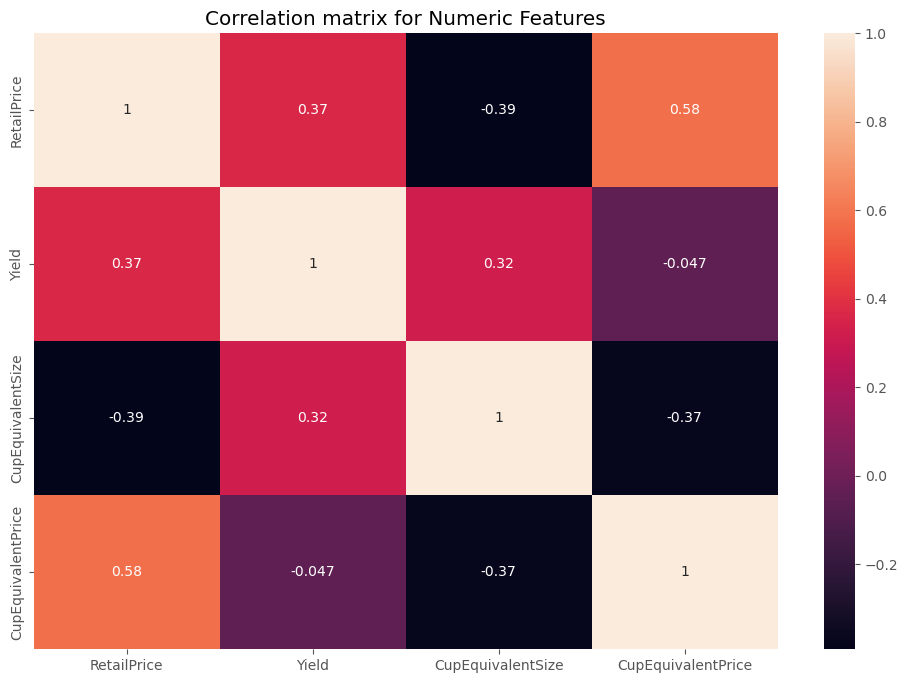

In [25]:
# create a correlation matrix for numerical categories only

correlation_matrix = df.corr(method = 'pearson', numeric_only = 'default')

sns.heatmap(correlation_matrix, annot = True)

plt.title("Correlation matrix")

plt.show()

In [26]:
# assign non-numeric categories a numerical value and use the pearson correlation method

df.apply(lambda x: x.factorize()[0]).corr(method='pearson')

,Fruit,Form,RetailPrice,RetailPriceUnit,Yield,CupEquivalentSize,CupEquivalentUnit,CupEquivalentPrice
Fruit,1.000000,0.003583,0.998848,0.083144,0.256232,0.097539,0.083144,0.998411
Form,0.003583,1.000000,0.022029,0.213146,-0.609741,0.126864,0.213146,0.021349
RetailPrice,0.998848,0.022029,1.000000,0.071957,0.248521,0.105554,0.071957,0.999821
RetailPriceUnit,0.083144,0.213146,0.071957,1.000000,-0.307940,-0.417899,1.000000,0.070539
Yield,0.256232,-0.609741,0.248521,-0.307940,1.000000,0.299482,-0.307940,0.249017
CupEquivalentSize,0.097539,0.126864,0.105554,-0.417899,0.299482,1.000000,-0.417899,0.102775
CupEquivalentUnit,0.083144,0.213146,0.071957,1.000000,-0.307940,-0.417899,1.000000,0.070539
CupEquivalentPrice,0.998411,0.021349,0.999821,0.070539,0.249017,0.102775,0.070539,1.000000


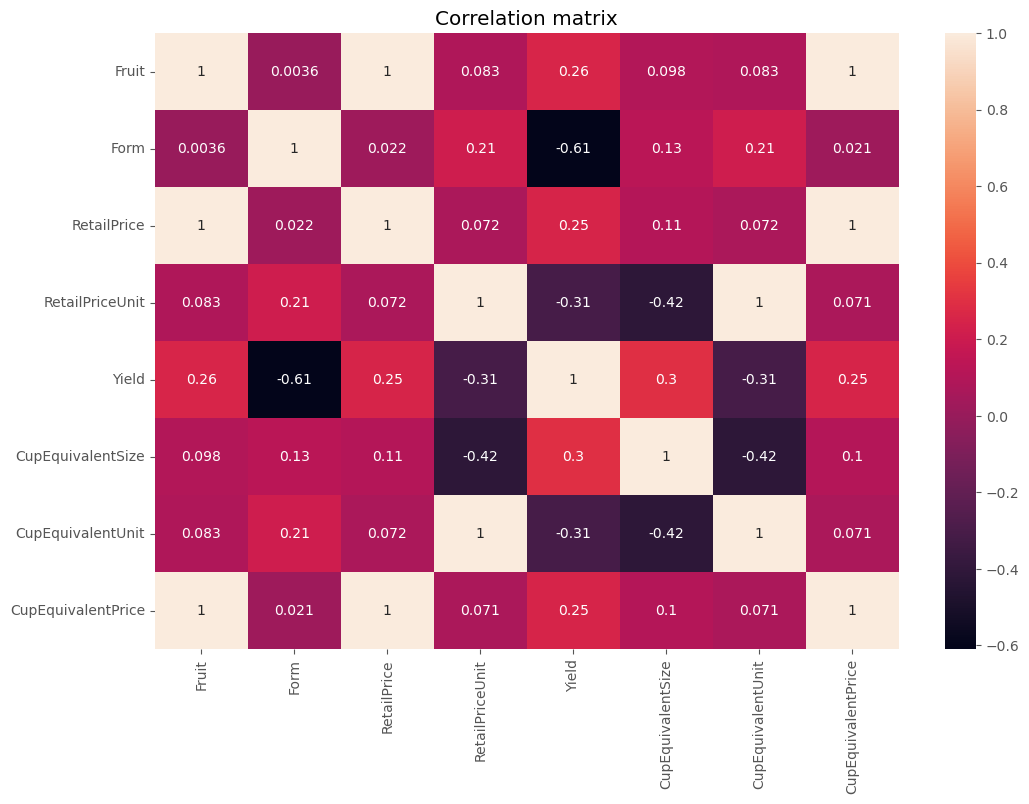

In [29]:
# correlation matrix for all categories

correlation_matrix = df.apply(lambda x: x.factorize()[0]).corr(method='pearson')

sns.heatmap(correlation_matrix, annot = True)

plt.title("Correlation matrix")

plt.show()

In [30]:
df_numerized.corr()

,Fruit,Form,RetailPrice,RetailPriceUnit,Yield,CupEquivalentSize,CupEquivalentUnit,CupEquivalentPrice
Fruit,1.000000,0.092741,-0.015200,-0.074983,-0.052111,0.074828,-0.074983,0.017321
Form,0.092741,1.000000,-0.259090,-0.736942,0.256604,0.728924,-0.736942,-0.333373
RetailPrice,-0.015200,-0.259090,1.000000,0.370365,0.367063,-0.391980,0.370365,0.578283
RetailPriceUnit,-0.074983,-0.736942,0.370365,1.000000,-0.331456,-0.999369,1.000000,0.376730
Yield,-0.052111,0.256604,0.367063,-0.331456,1.000000,0.321769,-0.331456,-0.046928
CupEquivalentSize,0.074828,0.728924,-0.391980,-0.999369,0.321769,1.000000,-0.999369,-0.372815
CupEquivalentUnit,-0.074983,-0.736942,0.370365,1.000000,-0.331456,-0.999369,1.000000,0.376730
CupEquivalentPrice,0.017321,-0.333373,0.578283,0.376730,-0.046928,-0.372815,0.376730,1.000000


In [40]:
# find category pairs that have a high correlation score > 0.5

corr_pairs = df_numerized.corr().unstack()

sorted_pairs = corr_pairs.sort_values()

high_corr = sorted_pairs[(sorted_pairs) > 0.5]

high_corr

CupEquivalentPrice  RetailPrice           0.578283
RetailPrice         CupEquivalentPrice    0.578283
Form                CupEquivalentSize     0.728924
CupEquivalentSize   Form                  0.728924
Fruit               Fruit                 1.000000
CupEquivalentUnit   RetailPriceUnit       1.000000
CupEquivalentSize   CupEquivalentSize     1.000000
Yield               Yield                 1.000000
RetailPriceUnit     CupEquivalentUnit     1.000000
                    RetailPriceUnit       1.000000
RetailPrice         RetailPrice           1.000000
Form                Form                  1.000000
CupEquivalentUnit   CupEquivalentUnit     1.000000
CupEquivalentPrice  CupEquivalentPrice    1.000000
dtype: float64

In [ ]:
# we find that the cup equivalent price has no significant correlation with the yield of the fruit
# we find that the cup equilvalent price has a significant correlation with the retail price
# we also find that the form of the fruit has a significant correlation with the cup equilvalent size of the fruit